### **Практическая работа \#5. Моделирование сети массового обслуживания.**

#### Выполнил: **Черных Арсений Игоревич**
#### Группа: **М3303**
#### Тема: **Система обработки сетевых запросов (Web-сервер)**

**Цель работы:**  
Исследовать характеристики сети массового обслуживания, в которой агенты (каналы обслуживания) могут подключаться и отключаться в произвольные моменты времени, с использованием методов имитационного моделирования.

---

### **Задачи:**

1. Разработать многоагентную модель сети массового обслуживания.  
2. Реализовать механизм подключения и отключения агентов (каналов обслуживания).  
3. Провести эксперименты и проанализировать влияние динамики агентов на характеристики сети.

---

### **Исходные данные:**

* Интенсивность входящего потока заявок (λ): задается вариантом (например, 10 заявок/час).  
* Интенсивность обслуживания одного агента (μ): задается вариантом (например, 3 заявки/час).  
* Количество агентов (каналов обслуживания): динамически изменяется от 1 до 5\.  
* Время моделирования: 1000 единиц времени (часы, минуты и т.д., в зависимости от контекста).

---

### **Шаги выполнения работы:**

1. Разработка модели:  
   * Создайте сеть массового обслуживания, состоящую из нескольких узлов.  
   * Реализуйте агентов (каналы обслуживания), которые могут подключаться и отключаться в произвольные моменты времени.  
   * Учтите, что заявки перемещаются между узлами сети в соответствии с заданными вероятностями переходов.  
2. Реализация динамики агентов:  
   * Агенты могут подключаться к сети с заданной интенсивностью (например, 1 агент/час).  
   * Агенты могут отключаться от сети с заданной интенсивностью (например, 0.5 агентов/час).  
   * Учтите, что отключенные агенты не могут обслуживать заявки.  
3. Проведение экспериментов:  
   * Запустите модель для заданных параметров.  
   * Зафиксируйте следующие показатели:  
     * Среднее время пребывания заявки в сети.  
     * Среднее число заявок в очереди.  
     * Среднее число активных агентов.  
     * Вероятность потери заявок (если очередь ограничена).  
4. Анализ результатов:  
   * Проведите анализ влияния динамики агентов на характеристики сети.  
   * Постройте графики зависимости среднего времени пребывания и длины очереди от числа активных агентов.  
   * Сделайте выводы о работе сети и предложите рекомендации по ее оптимизации.

---

### **Требования к отчету:**

1. Описание модели:  
   * Краткое описание сети и ее параметров.  
   * Описание алгоритма работы агентов.  
2. Результаты экспериментов:  
   * Таблицы с данными по каждому эксперименту.  
   * Графики зависимостей характеристик сети от числа активных агентов.  
3. Анализ результатов:  
   * Выводы о работе сети и рекомендации по ее оптимизации.

---

### **Инструменты для выполнения работы:**

* Язык программирования: Python (библиотеки `simpy`, `numpy`, `matplotlib`).  
* Программное обеспечение: AnyLogic, MATLAB (по выбору).



## Описание модели

В работе рассматривается сеть массового обслуживания, состоящая из двух узлов:

- **Узел 1** — основной узел приема и обслуживания заявок;
- **Узел 2** — дополнительный узел, в который часть заявок поступает после обслуживания в первом узле.

Логика движения заявок в сети следующая:

1. Заявки поступают во входной поток сети
2. Сначала каждая заявка попадает в узел 1
3. После завершения обслуживания в узле 1:
   - с вероятностью $p_{12}$ заявка переходит в узел 2;
   - с вероятностью $1 - p_{12}$ заявка покидает сеть.
4. После обслуживания в узле 2 заявка покидает сеть.

Для каждого узла задана очередь ожидания.  
Если в момент поступления заявки все активные агенты заняты, заявка помещается в очередь.  
Если очередь ограничена и заполнена, заявка считается потерянной.

### Динамика агентов

В каждом узле имеется некоторое число агентов обслуживания.  
Агенты могут:

- подключаться с интенсивностью $\alpha$
- отключаться с интенсивностью $\beta$

Число активных агентов ограничено диапазоном:
$
N_{\min} \leq N(t) \leq N_{\max}
$

Отключенный агент не участвует в обслуживании заявок
Активный агент может обслуживать не более одной заявки одновременно

## Параметры модели и расчетные показатели

В модели используются следующие параметры:

- $\lambda$ — интенсивность входного потока заявок;
- $\mu_1$ — интенсивность обслуживания в узле 1;
- $\mu_2$ — интенсивность обслуживания в узле 2;
- $p_{12}$ — вероятность перехода заявки из узла 1 в узел 2;
- $\alpha$ — интенсивность подключения агентов;
- $\beta$ — интенсивность отключения агентов;
- $N_{\min}$ — минимальное число активных агентов;
- $N_{\max}$ — максимальное число активных агентов;
- $T_{model}$ — время моделирования;
- $Q_{\max}$ — максимальная длина очереди.

### Стохастические предположения

Интервал между поступлениями заявок:
$
\Delta t \sim Exp(\lambda)
$

Время обслуживания в первом узле:
$
S_1 \sim Exp(\mu_1)
$

Время обслуживания во втором узле:
$
S_2 \sim Exp(\mu_2)
$

Интервал между событиями подключения агентов:
$
\Delta t_{on} \sim Exp(\alpha)
$

Интервал между событиями отключения агентов:
$
\Delta t_{off} \sim Exp(\beta)
$

### Основные показатели эффективности

#### Среднее время пребывания заявки в сети

Для каждой заявки:
$
T_i = t_i^{out} - t_i^{in}
$

Среднее время пребывания:
$
\overline{T} = \frac{1}{n}\sum_{i=1}^{n} T_i
$

#### Среднее число заявок в очереди

Средняя длина очереди определяется как:
$
\overline{L_q} = \frac{1}{T_{model}} \int_0^{T_{model}} L_q(t)\,dt
$

где $L_q(t)$ — число заявок в очереди в момент времени $t$

#### Среднее число активных агентов

Среднее число активных агентов:
$
\overline{A} = \frac{1}{T_{model}} \int_0^{T_{model}} A(t)\,dt
$

где $A(t)$ — число активных агентов в момент времени $t$

#### Вероятность потери заявок

Если очередь ограничена, вероятность потери определяется формулой:
$
P_{loss} = \frac{N_{loss}}{N_{arr}}
$

где:
- $N_{loss}$ — число потерянных заявок
- $N_{arr}$ — общее число поступивших заявок

In [30]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
lambda_rate = 4.0
mu1 = 3.0
mu2 = 4.0
p12 = 0.6

alpha = 1.0
beta = 0.5

min_agents = 1
max_agents = 5

queue_limit = 20
sim_time = 1000

In [32]:
class NetworkNode:
    def __init__(self, env, name, service_rate, min_agents, max_agents, queue_limit):
        self.env = env
        self.name = name
        self.service_rate = service_rate
        self.min_agents = min_agents
        self.max_agents = max_agents
        self.queue_limit = queue_limit

        self.queue = []
        self.active_agents = min_agents
        self.busy_agents = 0

        self.last_queue_change_time = 0
        self.last_agents_change_time = 0

        self.queue_area = 0
        self.agents_area = 0

        self.total_served = 0
        self.total_lost = 0

        self.agent_history_time = [0]
        self.agent_history_value = [self.active_agents]

    def update_queue_stat(self):
        dt = self.env.now - self.last_queue_change_time
        self.queue_area += len(self.queue) * dt
        self.last_queue_change_time = self.env.now

    def update_agents_stat(self):
        dt = self.env.now - self.last_agents_change_time
        self.agents_area += self.active_agents * dt
        self.last_agents_change_time = self.env.now

    def add_request(self, request, next_step=None):
        if self.busy_agents < self.active_agents:
            self.busy_agents += 1
            self.env.process(self.serve(request, next_step))
        else:
            if len(self.queue) < self.queue_limit:
                self.update_queue_stat()
                self.queue.append((request, next_step))
            else:
                self.total_lost += 1
                request["lost"] = True

    def serve(self, request, next_step=None):
        service_time = np.random.exponential(1 / self.service_rate)
        yield self.env.timeout(service_time)

        self.total_served += 1
        self.busy_agents -= 1

        if next_step is not None and not request.get("lost", False):
            next_step(request)

        if self.queue and self.busy_agents < self.active_agents:
            self.update_queue_stat()
            next_request, next_request_step = self.queue.pop(0)
            self.busy_agents += 1
            self.env.process(self.serve(next_request, next_request_step))

    def connect_agent(self):
        if self.active_agents < self.max_agents:
            self.update_agents_stat()
            self.active_agents += 1
            self.agent_history_time.append(self.env.now)
            self.agent_history_value.append(self.active_agents)
            self.try_start_service()

    def disconnect_agent(self):
        if self.active_agents > self.min_agents and self.busy_agents < self.active_agents:
            self.update_agents_stat()
            self.active_agents -= 1
            self.agent_history_time.append(self.env.now)
            self.agent_history_value.append(self.active_agents)

    def try_start_service(self):
        while self.queue and self.busy_agents < self.active_agents:
            self.update_queue_stat()
            request, next_step = self.queue.pop(0)
            self.busy_agents += 1
            self.env.process(self.serve(request, next_step))

    def finalize_stats(self):
        self.update_queue_stat()
        self.update_agents_stat()

    def get_avg_queue_length(self):
        if self.env.now == 0:
            return 0
        return self.queue_area / self.env.now

    def get_avg_active_agents(self):
        if self.env.now == 0:
            return 0
        return self.agents_area / self.env.now

In [33]:
def agent_dynamics(env, node, alpha, beta):
    while True:
        time_to_change = np.random.exponential(1 / (alpha + beta))
        yield env.timeout(time_to_change)

        event_type = np.random.choice(["connect", "disconnect"], p=[alpha / (alpha + beta), beta / (alpha + beta)])

        if event_type == "connect":
            node.connect_agent()
        else:
            node.disconnect_agent()

In [34]:
def request_flow(env, request, node1, node2, p12, completed_times, transition_stats, transition_history):
    def after_node1(req):
        if np.random.rand() < p12:
            transition_stats["node1_to_node2"] += 1
            transition_history.append((env.now, "node1_to_node2"))
            node2.add_request(req, after_node2)
        else:
            transition_stats["node1_exit"] += 1
            transition_history.append((env.now, "node1_exit"))
            req["end_time"] = env.now
            completed_times.append(req["end_time"] - req["start_time"])

    def after_node2(req):
        transition_stats["node2_exit"] += 1
        transition_history.append((env.now, "node2_exit"))
        req["end_time"] = env.now
        completed_times.append(req["end_time"] - req["start_time"])

    node1.add_request(request, after_node1)
    yield env.timeout(0)

In [35]:
def request_generator(env, node1, node2, lambda_rate, p12, completed_times, all_requests, transition_stats, transition_history):
    request_id = 0

    while True:
        interarrival = np.random.exponential(1 / lambda_rate)
        yield env.timeout(interarrival)

        request = {
            "id": request_id,
            "start_time": env.now,
            "lost": False
        }

        all_requests.append(request)
        env.process(
            request_flow(
                env,
                request,
                node1,
                node2,
                p12,
                completed_times,
                transition_stats,
                transition_history
            )
        )

        request_id += 1

In [36]:
def run_simulation(
    lambda_rate,
    mu1,
    mu2,
    p12,
    alpha,
    beta,
    min_agents,
    max_agents,
    queue_limit,
    sim_time
):
    env = simpy.Environment()

    transition_stats = {
        "node1_to_node2": 0,
        "node1_exit": 0,
        "node2_exit": 0
    }

    transition_history = []

    node1 = NetworkNode(env, "node1", mu1, min_agents, max_agents, queue_limit)
    node2 = NetworkNode(env, "node2", mu2, min_agents, max_agents, queue_limit)

    completed_times = []
    all_requests = []

    env.process(agent_dynamics(env, node1, alpha, beta))
    env.process(agent_dynamics(env, node2, alpha, beta))
    env.process(
        request_generator(
            env,
            node1,
            node2,
            lambda_rate,
            p12,
            completed_times,
            all_requests,
            transition_stats,
            transition_history
        )
    )

    env.run(until=sim_time)

    node1.finalize_stats()
    node2.finalize_stats()

    total_arrived = len(all_requests)
    total_lost = sum(1 for req in all_requests if req["lost"])
    loss_probability = total_lost / total_arrived if total_arrived > 0 else 0

    avg_time_in_system = np.mean(completed_times) if completed_times else 0

    avg_queue_length_node1 = node1.get_avg_queue_length()
    avg_queue_length_node2 = node2.get_avg_queue_length()
    avg_queue_length = avg_queue_length_node1 + avg_queue_length_node2

    avg_active_agents_node1 = node1.get_avg_active_agents()
    avg_active_agents_node2 = node2.get_avg_active_agents()
    avg_active_agents = avg_active_agents_node1 + avg_active_agents_node2

    return {
        "avg_time_in_system": avg_time_in_system,
        "avg_queue_length_node1": avg_queue_length_node1,
        "avg_queue_length_node2": avg_queue_length_node2,
        "avg_queue_length": avg_queue_length,
        "avg_active_agents_node1": avg_active_agents_node1,
        "avg_active_agents_node2": avg_active_agents_node2,
        "avg_active_agents": avg_active_agents,
        "loss_probability": loss_probability,
        "total_arrived": total_arrived,
        "total_lost": total_lost,
        "total_served_node1": node1.total_served,
        "total_served_node2": node2.total_served,
        "node1_to_node2": transition_stats["node1_to_node2"],
        "node1_exit": transition_stats["node1_exit"],
        "node2_exit": transition_stats["node2_exit"],
        "transition_history": transition_history,
        "node1_agent_history_time": node1.agent_history_time,
        "node1_agent_history_value": node1.agent_history_value,
        "node2_agent_history_time": node2.agent_history_time,
        "node2_agent_history_value": node2.agent_history_value,
    }

In [48]:
base_result = run_simulation(
    lambda_rate=lambda_rate,
    mu1=mu1,
    mu2=mu2,
    p12=p12,
    alpha=alpha,
    beta=beta,
    min_agents=min_agents,
    max_agents=max_agents,
    queue_limit=queue_limit,
    sim_time=sim_time
)

## Проведение экспериментов

Для анализа влияния динамики агентов на характеристики сети проведем серию экспериментов.  
Будем изменять интенсивность отключения агентов $\beta$, оставляя остальные параметры фиксированными.

Для каждого эксперимента определяются:
- среднее время пребывания заявки в сети;
- среднее число заявок в очереди;
- среднее число активных агентов;
- вероятность потери заявок.

In [53]:
beta_values = [0.1, 0.3, 0.5, 0.7, 1.0]

results = []

for current_beta in beta_values:
    result = run_simulation(
        lambda_rate=lambda_rate,
        mu1=mu1,
        mu2=mu2,
        p12=p12,
        alpha=alpha,
        beta=current_beta,
        min_agents=min_agents,
        max_agents=max_agents,
        queue_limit=queue_limit,
        sim_time=sim_time
    )

    result["beta"] = current_beta
    results.append(result)

df_results = pd.DataFrame(results)[[
    "beta",
    "avg_time_in_system",
    "avg_queue_length",
    "avg_active_agents",
    "total_arrived",
]].round(4)

df_results

,beta,avg_time_in_system,avg_queue_length,avg_active_agents,total_arrived
0,0.1,0.4893,0.0131,9.7594,3951
1,0.3,0.4817,0.0205,9.2222,4106
2,0.5,0.5246,0.1488,8.4095,3899
3,0.7,0.5374,0.1917,7.7153,3980
4,1.0,0.5994,0.4780,6.5317,4098


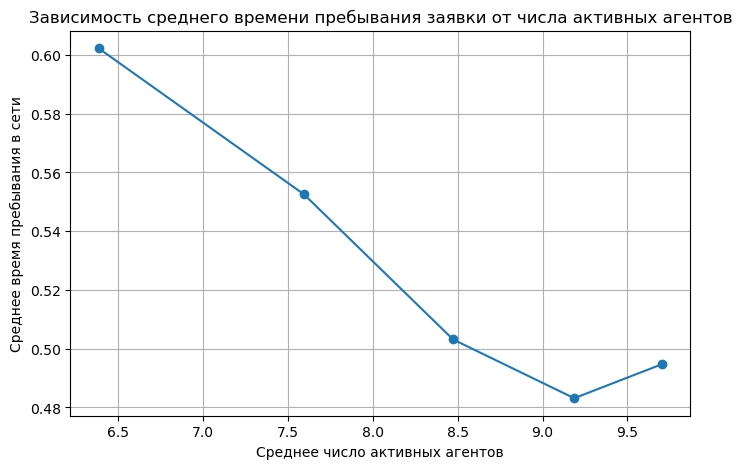

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["avg_active_agents"], df_results["avg_time_in_system"], marker="o")
plt.xlabel("Среднее число активных агентов")
plt.ylabel("Среднее время пребывания в сети")
plt.title("Зависимость среднего времени пребывания заявки от числа активных агентов")
plt.grid(True)
plt.show()

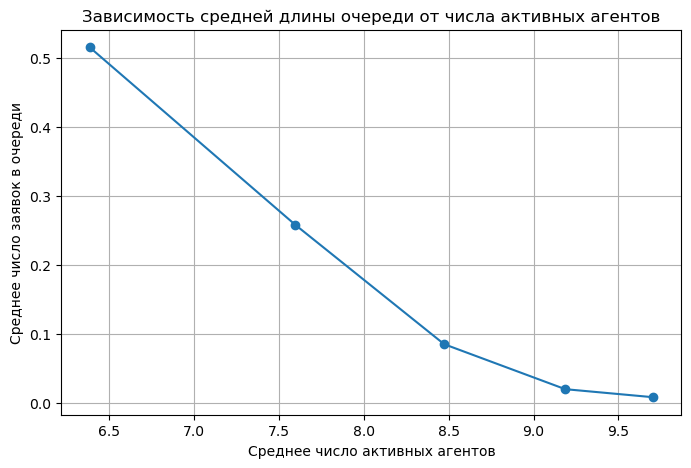

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["avg_active_agents"], df_results["avg_queue_length"], marker="o")
plt.xlabel("Среднее число активных агентов")
plt.ylabel("Среднее число заявок в очереди")
plt.title("Зависимость средней длины очереди от числа активных агентов")
plt.grid(True)
plt.show()

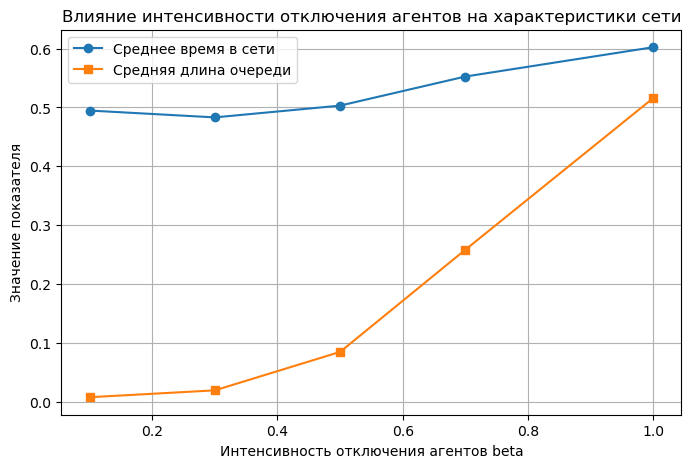

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["beta"], df_results["avg_time_in_system"], marker="o", label="Среднее время в сети")
plt.plot(df_results["beta"], df_results["avg_queue_length"], marker="s", label="Средняя длина очереди")
plt.xlabel("Интенсивность отключения агентов beta")
plt.ylabel("Значение показателя")
plt.title("Влияние интенсивности отключения агентов на характеристики сети")
plt.grid(True)
plt.legend()
plt.show()

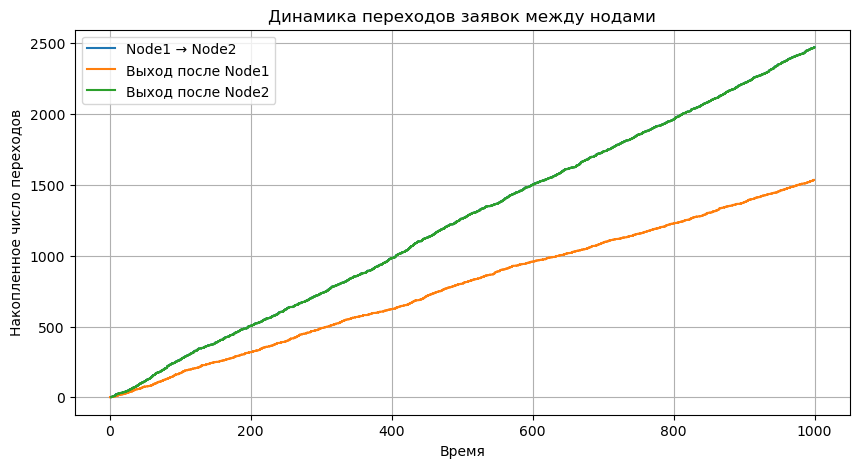

Последнее значение 1->2: 2472
Последнее значение 1->exit: 1535
Последнее значение 2->exit: 2471


In [56]:
times_12 = []
times_1_exit = []
times_2_exit = []

for t, tp in base_result["transition_history"]:
    if tp == "node1_to_node2":
        times_12.append(t)
    elif tp == "node1_exit":
        times_1_exit.append(t)
    elif tp == "node2_exit":
        times_2_exit.append(t)

plt.figure(figsize=(10, 5))

if times_12:
    plt.step(sorted(times_12), range(1, len(times_12) + 1), where="post", label="Node1 → Node2")
if times_1_exit:
    plt.step(sorted(times_1_exit), range(1, len(times_1_exit) + 1), where="post", label="Выход после Node1")
if times_2_exit:
    plt.step(sorted(times_2_exit), range(1, len(times_2_exit) + 1), where="post", label="Выход после Node2")

plt.xlabel("Время")
plt.ylabel("Накопленное число переходов")
plt.title("Динамика переходов заявок между нодами")
plt.grid(True)
plt.legend()
plt.show()

print("Последнее значение 1->2:", len(times_12))
print("Последнее значение 1->exit:", len(times_1_exit))
print("Последнее значение 2->exit:", len(times_2_exit))

## Анализ результатов и вывод

По результатам моделирования можно сделать следующие выводы:

1. При увеличении интенсивности отключения агентов $\beta$ среднее число активных агентов в сети уменьшается
2. Уменьшение числа активных агентов приводит к росту средней длины очереди
3. При снижении доступности агентов увеличивается среднее время пребывания заявки в сети
4. В проведённых экспериментах потерь заявок не наблюдалось, однако при увеличении нагрузки или уменьшении длины очереди вероятность потерь может возраст
5. Наиболее устойчивый режим работы сети достигается при меньшей интенсивности отключения агентов и достаточном резерве активных каналов

Таким образом, динамика агентов оказывает существенное влияние на эффективность сети массового обслуживания. Для повышения производительности сети необходимо уменьшать частоту отключения агентов или обеспечивать возможность быстрого подключения дополнительных каналов обслуживания.

График динамики переходов между нодами подверждает, что переходы реализованы правильно и системы не перегружена
